# Dopsca OCEANSAR simulation analysis

In [1]:
%load_ext autoreload
%autoreload 2

In [20]:
import os
import numpy as np
from matplotlib import pyplot as plt
import xarray as xr
from drama import utils as drtls
import drama.geo as drgeo
import drama.performance.oscillators as drosc
from oceansar.dopscasim.dopsca_sys import dopsca_syssim

In [55]:
rawfile = "/Users/plopezdekker/LocalDATA/OceanSAR/dopsca_test_16x10km/raw_data.nc"
simdir =  "/Users/plopezdekker/LocalDATA/OceanSAR/dopsca_TSC0d0_U10d0_16x10km"
rawfile = os.path.join(simdir, "ideal_raw_data.nc")
sysfile = os.path.join(simdir, "sys_raw_data.nc")

scaraw_sys  = xr.open_dataset(sysfile,engine='h5netcdf')
scaraw_sys = scaraw_sys.load()
scaraw_sys.close()

In [22]:
scaraw_sys

<xarray.Dataset> Size: 4MB
Dimensions:             (pol_dim: 2, az_dim: 38, rg_dim: 1582)
Dimensions without coordinates: pol_dim, az_dim, rg_dim
Data variables: (12/17)
    raw_data_r          (pol_dim, az_dim, rg_dim) float64 962kB 0.0823 ... 0.0
    raw_data_i          (pol_dim, az_dim, rg_dim) float64 962kB -0.0199 ... 0.0
    dop_ref             (rg_dim) float64 13kB 9.969e+36 9.969e+36 ... 9.969e+36
    inc_angle           float64 8B 35.0
    f0                  float64 8B 5.4e+09
    ant_L               float64 8B 3.0
    ...                  ...
    rg_bw               float64 8B 1e+06
    azimuth             float64 8B 9.969e+36
    subpulse_length     float64 8B 0.0001
    subpulse_bandwidth  float64 8B 1e+06
    NRCS_avg            (pol_dim, az_dim) float64 608B 0.1748 0.1748 ... 0.6293
    craw                (pol_dim, az_dim, rg_dim) complex128 2MB (0.038722335...
Attributes:
    description:  OCEANSAR SAR Raw Data File
    history:      Created Sun Jan 18 10:45:18 2026
    source:       OCEANSAR Dopsca Simulator

In [7]:
cfg_file = '/Users/plopezdekker/Documents/CODE/oceansar/par/dopsca.cfg'
scaraw2 = dopsca_syssim(cfg_file,add_noise=True, clock_errors=True)
scaraw2_noerr = dopsca_syssim(cfg_file,output_file=None, add_noise=False, clock_errors=False)

(array([ 0, -1, -2, -3, -4]), array([2.88970931e-16, 1.26820650e-12, 9.47991923e-11, 5.63819498e-12,
       0.00000000e+00]))


In [43]:
def dpsca_coh(scaraw, rg_ml=None, raw=False):
    fs = scaraw.rg_sampling.values
    print("Sampling frequency: %f", fs)
    subpulse_length = scaraw.subpulse_length.values
    offset_smp = subpulse_length * fs
    if raw:
        prof =  scaraw['raw_data_r'].values + 1j * scaraw['raw_data_i'].values
    else:
        prof = scaraw['craw'].values
    prof_corr = np.roll(prof,-int(offset_smp), axis=2)
    corr = prof_corr * np.conj(prof)
    nrcs_prof = np.abs(prof)**2
    geom = drgeo.QuickRadarGeometry(scaraw.orbit_alt.values)
    sr0 = scaraw.sr0.values
    sr = sr0 + 3e8 * np.arange(scaraw.rg_dim.size) / (2 * scaraw.rg_sampling.values)
    gr = geom.sr_to_gr(sr)
    range_scaling = (sr0 / sr)**2
    if rg_ml is None:
        coh = np.mean(corr[:,:], axis=1) / np.sqrt(np.mean(np.abs(prof[:,:])**2, axis=1) * np.mean(np.abs(prof_corr[:,:])**2, axis=1))
        nrcs_prof = np.mean(nrcs_prof, axis=1)
    else:
        nrcs_prof = drtls.smooth(np.mean(nrcs_prof, axis=1), rg_ml, axis=1)
        corr = drtls.smooth(np.mean(corr, axis=1), rg_ml, axis=1)
        coh = corr/np.sqrt(nrcs_prof*np.roll(nrcs_prof,-int(offset_smp),axis=1))
    rvel = np.angle(coh)/(2*np.pi*scaraw.subpulse_length.values)*3e8/2/scaraw.f0.values
    return nrcs_prof/range_scaling, coh, rvel

def plot_dpsca(scaraw, nrcs_prof, coh_20, coh_200, nrglk, fontsize=10):
    # Page settings
    page_width_in = 8.27      # A4 width in inches; use 8.5 for Letter
    left_margin = 0.75       # inches
    right_margin = 0.75      # inches
    # Compute figure size
    fig_width = page_width_in - left_margin - right_margin
    fig_height = 10 * (fig_width / 14.0)   # scale original height (14x3.5 -> keep aspect). Adjust as you like.
    # Set global font size
    plt.rcParams.update({'font.size': fontsize})
    # Create figure sized to page width (with margins considered)
    geom = drgeo.QuickRadarGeometry(scaraw.orbit_alt.values)
    sr0 = scaraw.sr0.values
    sr = sr0 + 3e8 * np.arange(scaraw.rg_dim.size) / (2 * scaraw.rg_sampling.values)
    gr = geom.sr_to_gr(sr)
    range_scaling = (sr0 / sr)**2
    fig, axs = plt.subplots(2, 2, figsize=(fig_width, fig_height), constrained_layout=True)

    axs[0,0].plot(gr*1e-3, drtls.db(nrcs_prof[1]))
    #axs[0,0].set_xlabel('Range sample')
    axs[0,0].set_ylabel('NRCS')
    axs[0,1].plot(gr*1e-3, np.abs(coh_20[1]))
    #axs[0,1].set_xlabel('Range sample')
    axs[0,1].set_ylabel('Coherence magnitude')
    rvel = np.angle(coh_200)/(2*np.pi*scaraw.subpulse_length.values)*3e8/2/scaraw.f0.values
    axs[1,0].plot(gr*1e-3, rvel[1])
    #axs[1,0].set_xlabel('Range sample')
    axs[1,0].set_ylabel('Doppler velocity [m/s]')
    axs[1,0].set_ylim(-5,5)
    nlk = nrglk * scaraw['raw_data_r'].values.shape[1]
    axs[1,1].plot(gr*1e-3, np.sqrt((1. - np.abs(coh_200[1]) ** 2.) / (2. * nlk * np.abs(coh_200[1]) ** 2.))/(2*np.pi*scaraw.subpulse_length.values)*3e8/2/scaraw.f0.values)
    #axs[1,1].set_xlabel('Ground range [km]')
    axs[1,1].set_ylabel('Doppler uncertainty [m/s]')
    axs[1,1].set_ylim(0,2)
    #plt.tight_layout()
    for ax in axs.flatten():
        ax.set_xlabel('Ground range [km]')
        ax.grid()




<>:22: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
<>:22: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
/var/folders/kk/65qkkvqd6vz1crfx4px3l5cc_8rpy_/T/ipykernel_64388/3352064827.py:22: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
  plt.ylabel('$\Delta v_D$ [m/s]')


Sampling frequency: %f 2000000.0
Sampling frequency: %f 2000000.0
Sampling frequency: %f 2000000.0
Sampling frequency: %f 2000000.0


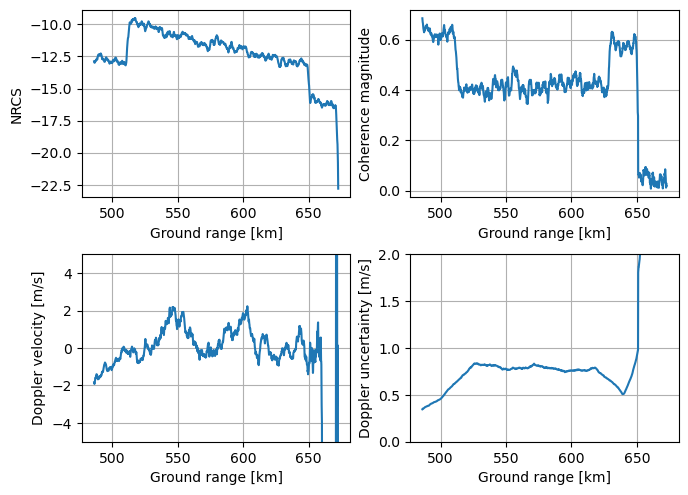

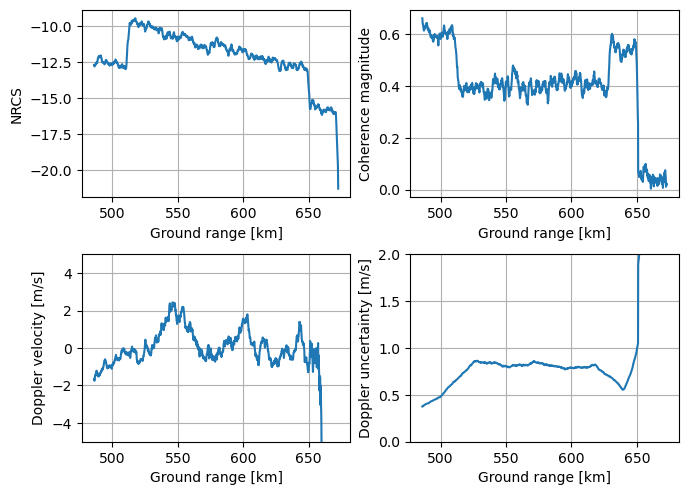

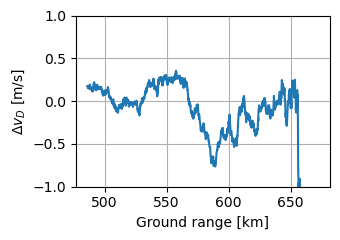

In [56]:
rml2 = 200
nrcs_prof, coh_20, rvel_20 = dpsca_coh(scaraw_sys, rg_ml=20, raw=True)
nrcs_prof_200, coh_200, rvel_200_nonoise = dpsca_coh(scaraw_sys, rg_ml=rml2, raw=True)
plot_dpsca(scaraw_sys, nrcs_prof, coh_20, coh_200, rml2,fontsize=10)

nrcs2_prof, coh2_20, rvel_20 = dpsca_coh(scaraw_sys, rg_ml=20, raw=False)
nrcs2_prof_200, coh2_200, rvel_200 = dpsca_coh(scaraw_sys, rg_ml=rml2, raw=False)
plot_dpsca(scaraw_sys, nrcs2_prof, coh2_20, coh2_200, rml2,fontsize=10)
figdir = os.path.join(simdir, "proc_plots")
os.makedirs(figdir, exist_ok=True)
plt.savefig(os.path.join(figdir,'nrcs_coh_dop.png'), dpi=300)

geom = drgeo.QuickRadarGeometry(scaraw_sys.orbit_alt.values)
sr0 = scaraw.sr0.values
sr = sr0 + 3e8 * np.arange(scaraw_sys.rg_dim.size) / (2 * scaraw_sys.rg_sampling.values)
gr = geom.sr_to_gr(sr)
plt.figure(figsize=(3.5,2.5))
plt.plot(gr/1e3, rvel_200[1]-rvel_200_nonoise[1])
plt.ylim(-1,1)
plt.grid()
plt.xlabel('Ground range [km]')
plt.ylabel('$\Delta v_D$ [m/s]')
plt.tight_layout()
plt.savefig(os.path.join(figdir,'system_introduced_dop.png'), dpi=300)


# nrcs2_noerr_prof, coh2_noerr_20 = dpsca_coh(scaraw2_noerr, rg_ml=20, raw=True)
# nrcs2_noerr_prof_200, coh2_noerr_200 = dpsca_coh(scaraw2_noerr, rg_ml=rml2, raw=True)
# plot_dpsca(scaraw2_noerr, nrcs2_noerr_prof, coh2_noerr_20, coh2_noerr_200, rml2,fontsize=10)

In [39]:
200/2e6*3e8/2/np.sin(np.radians(40))
0.4/1e-4/360/np.sqrt(40)*0.05/2

np.float64(0.04392052305789415)

In [42]:
2/0.05

40.0

In [29]:
scaraw.close()

(array([ 0, -1, -2, -3, -4]), array([2.88970931e-16, 1.26820650e-12, 9.47991923e-11, 5.63819498e-12,
       0.00000000e+00]))
1.36783597917156e-25


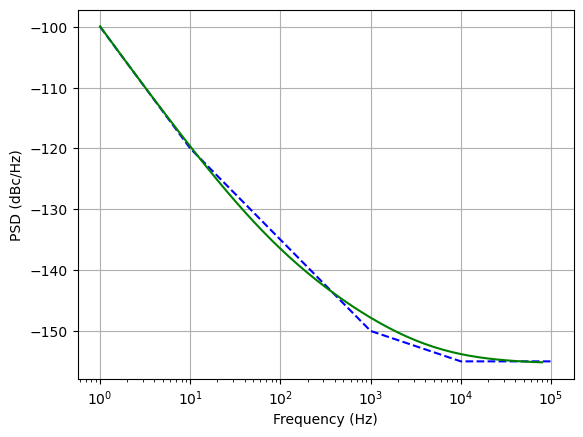

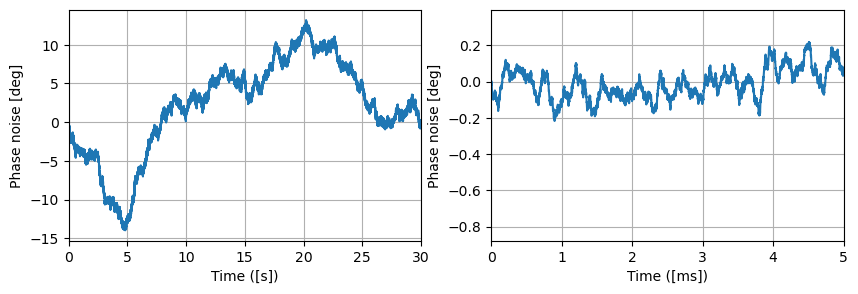

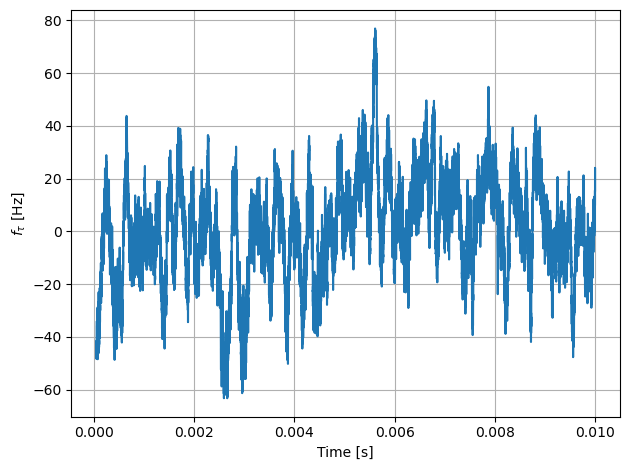

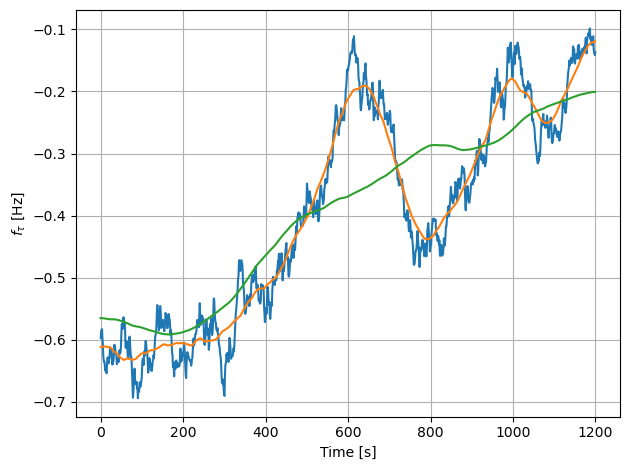

In [41]:
from drama.performance.oscillators.phasenoisesim import plot_freq
osc_coef = drosc.measured2coef(type="SAOCOM")
print(osc_coef)
pnoise, S,f = drosc.phasenoise(20, 1/2e3, osc_coef[0], osc_coef[1])
pnoise.shape
pnoise2, S2,f2 = drosc.phasenoise(20e-3, 1/2e6, osc_coef[0], osc_coef[1])
fix, axs = plt.subplots(1,2, figsize=(10,3))
axs[0].plot(np.arange(pnoise.size)/2e3, np.degrees(pnoise.flatten()-pnoise[0])*5.4e9/10e6)
axs[0].set_xlabel('Time ([s])')
axs[0].set_ylabel('Phase noise [deg]')
axs[0].set_xlim(0, 30)
axs[0].grid()
fpnoise = np.roll(drtls.smooth(pnoise2.flatten()-pnoise2.flatten()[0],int(2e6*0.1e-3)),-400)
axs[1].plot(np.arange(pnoise2.size)/2e3, np.degrees(fpnoise - fpnoise[0])*5.4e9/10e6)
axs[1].set_xlabel('Time ([ms])')
axs[1].set_ylabel('Phase noise [deg]')
axs[1].set_xlim(0, 5)
axs[1].grid()

#plot_freq(pnoise*5.4e9/10e6, 1/2e3, 0.1, toff=0,xlim=(0, 10))
plot_freq(pnoise*5.4e9/10e6, 1/2e6, 1e-4, toff=0,xlim=(0, 10e-3))
#plot_freq(pnoise*5.4e9/10e6, 1/2e6, 1e-3, toff=0,xlim=(0, 10e-3), overplot=True)

h_2 = (3e-11) ** 2 * 3 / (2 * np.pi ** 2 * 1e3)
print(h_2)
p, S2,f2 = drosc.phasenoise(10000, 1, -4, h_2)
pCband = p * 5.4e9
plot_freq(pCband, 1, 1, xlim=(0, 1200))
plot_freq(pCband, 1, 100, overplot=True, xlim=(0, 1200))
plot_freq(pCband, 1, 500, overplot=True, xlim=(0, 1200))

/var/folders/kk/65qkkvqd6vz1crfx4px3l5cc_8rpy_/T/ipykernel_15480/1413600141.py:1: RuntimeWarning: divide by zero encountered in log10
  plt.plot(f[0:int(32768/2)],10*np.log10(S[0:int(32768/2)]/f[1]))


131072

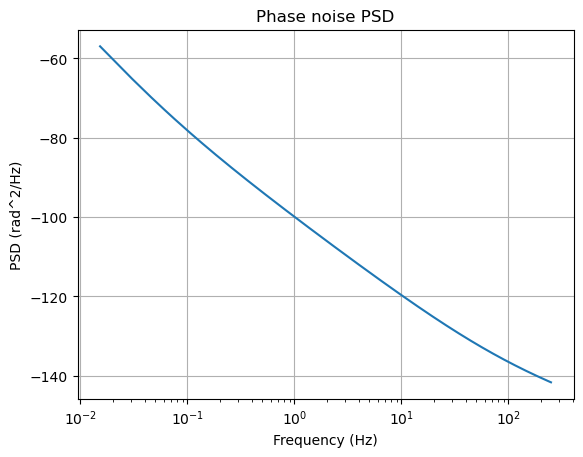

In [6]:
plt.plot(f[0:int(32768/2)],10*np.log10(S[0:int(32768/2)]/f[1]))
#plt.yscale('log')
plt.xscale('log')
plt.xlabel('Frequency (Hz)')
plt.ylabel('PSD (rad^2/Hz)')
plt.title('Phase noise PSD')
plt.grid()
S.size

In [47]:
100e3/(3e8/2/2e6*2)

666.6666666666666

In [10]:
0.05/3*1e6

16666.666666666668

In [57]:
16e3 /3e8 * 2e6

106.66666666666667